# ECE 57000 Project

TinyReproductions: Mixup

By:Andy Tan

# Instructions to run are in the README


# Packages (NECESSARY TO RUN)

In [2]:
import time # for start and end times
from typing import List, Dict


# Torch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

import matplotlib.pyplot as plt # for plotting

import numpy as np # For math

import pandas as pd # Pandas for csv

# Set Seed
torch.manual_seed(1) #https://docs.pytorch.org/docs/stable/generated/torch.manual_seed.html#torch.manual_seed

# ERM Setup (NECESSARY TO RUN)
Train and Test Functions are copied from self-submission of Assignment 3: CNN

In [3]:
def train(model: nn.Module,
          loss_fn: nn.modules.loss._Loss,
          optimizer: torch.optim.Optimizer,
          train_loader: torch.utils.data.DataLoader,
          epoch: int=1)-> List:
    # ----------- <Your code> ---------------
    # Reference for Module https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
    model.train()
    # Use example to enable GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Reference for Dataloader https://docs.pytorch.org/docs/stable/data.html

    # Get batches per epoch to print 8 times per epoch
# https://stackoverflow.com/questions/63930621/how-to-get-the-total-number-of-batch-iteration-from-pytorch-dataloader
    printInterval = len(train_loader) // 8

    # Edge case where fewer than 1 batch size
    if printInterval < 1:
      printInterval = 1

    # Loss List
    train_loss = []

# Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    for batch_idx, batch in enumerate(train_loader):
      images = batch[0]
      images = images.to(device)

      labels = batch[1]
      labels = labels.to(device)

      # zero gradient to not accumulate
      optimizer.zero_grad()

      # Forward
      outputs = model(images)
      loss = loss_fn(outputs, labels)

      # Backward
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

      if batch_idx % printInterval == 0:
        print(f'Epoch {epoch}: [{batch_idx*len(images)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

    # ----------- <End Your code> ---------------
    assert len(train_loss) == len(train_loader)
    return train_loss

def test(model: nn.Module,
         loss_fn: nn.modules.loss._Loss,
         test_loader: torch.utils.data.DataLoader,
         epoch: int=1)-> Dict:
    # ----------- <Your code> ---------------
    # Refer https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    correct = 0
    lossTotal = 0
    total_num = 0
    predictionTotal = []

    # Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    with torch.no_grad(): # No gradient calculations since testing
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # len to return batch size
        sampleNum = len(images)
        output = model(images)

        # Accumulate loss but factor in that the last batch may have a different sample size
        lossTotal += loss_fn(output, labels).item() * sampleNum
        # Torch max returns score and highest prediction. Do not need score
        _, prediction = torch.max(output,1)

        # .item() for memory
        total_num += sampleNum
        correct += (prediction == labels).sum().item()
        # From online, adding the .cpu moves it to cpu to not bottleneck GPU
        predictionTotal.append(prediction.cpu())

    avgLoss = lossTotal / total_num
    accuracy = correct / total_num
    predictions = torch.cat(predictionTotal, dim=0) # Flatten

    test_stat = {"loss": avgLoss, "accuracy": accuracy, "prediction":predictions}
    print(f"Test result on epoch {epoch}: total sample: {total_num}, Avg loss: {test_stat['loss']:.3f}, Acc: {100*test_stat['accuracy']:.3f}%")

    # ----------- <End Your code> ---------------
    # dictionary should include loss, accuracy and prediction
    assert "loss" and "accuracy" and "prediction" in test_stat.keys()
    # "prediction" value should be a 1D tensor
    assert len(test_stat["prediction"]) == len(test_loader.dataset)
    assert isinstance(test_stat["prediction"], torch.Tensor)
    return test_stat


 # data loaders for CIFAR-10 No corruption
 Cell block is copied from self-submission of Assignment 3: CNN

100%|██████████| 170M/170M [00:06<00:00, 24.6MB/s]


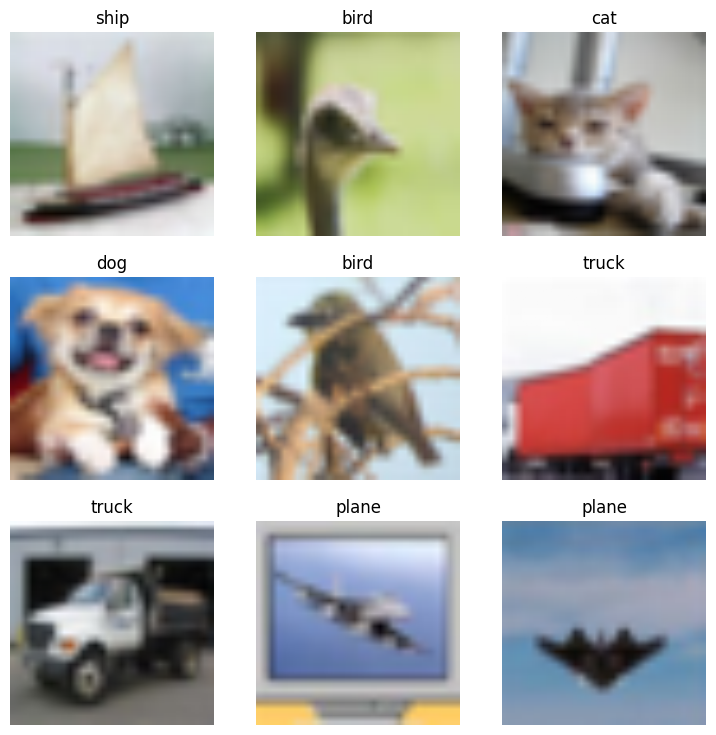

In [3]:
# Create your dataloader here
# ----------- <Your code> ---------------
transform = transforms.Compose(
    [transforms.Resize(224),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Train and Test Set Load (Reset)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Adjust for noise
batchSize = 64

train_loader = torch.utils.data.DataLoader(dataset=trainset, batch_size=batchSize, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=batchSize, shuffle=False)


classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
batch_idx, (images, targets) = next(enumerate(train_loader)) #fix!!!!!
fig, ax = plt.subplots(3,3,figsize = (9,9))
for i in range(3):
    for j in range(3):
        image = images[i*3+j].permute(1,2,0)
        image = image/2 + 0.5
        ax[i,j].imshow(image)
        ax[i,j].set_axis_off()
        ax[i,j].set_title(f'{classes[targets[i*3+j]]}')
fig.show()

# Resnet 18 (ERM) 1 epoch

This is a test from Checkpoint 2 of ERM for one epoch adapted from Assignment 3: CNN

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Directly train the whole model.
start = time.time()
#----------- <Your code> ---------------
# Reload Resnet18 in case of changes
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Have to edit last layer to 10 output channels for CIFAR10 match
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 10)

# Send to GPU
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
max_epoch = 1

optimizer = optim.SGD(resnet18.parameters(), lr=0.001, momentum=0.9)

# Run train and test (uncomment when running just mixup)
for epoch in range(1, max_epoch + 1):
    train(resnet18, criterion, optimizer, train_loader, epoch)
    test(resnet18, criterion, test_loader, epoch)
# ----------- <End Your code> ---------------
test(resnet18, criterion, test_loader, epoch)
end = time.time()
print(f'Finished Training after {end-start} s ')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 430MB/s]


Epoch 1: [0/50000] Loss: 2.393
Epoch 1: [6208/50000] Loss: 0.741
Epoch 1: [12416/50000] Loss: 0.484
Epoch 1: [18624/50000] Loss: 0.312
Epoch 1: [24832/50000] Loss: 0.259
Epoch 1: [31040/50000] Loss: 0.378
Epoch 1: [37248/50000] Loss: 0.262
Epoch 1: [43456/50000] Loss: 0.533
Epoch 1: [49664/50000] Loss: 0.253
Test result on epoch 1: total sample: 10000, Avg loss: 0.223, Acc: 92.470%
Test result on epoch 1: total sample: 10000, Avg loss: 0.223, Acc: 92.470%
Finished Training after 48.2497615814209 s 


# Mixup Custom Functions (NECESSARY TO RUN)
Checkpoint 2 Update: Transition from numpy to torch implementation. Found replacement functions and reimplement.

In [4]:

def mixup(x, y, alpha):
    # If alpha (hyper parameter) is > 0, create a lambda value based on a beta distribution, else lambda is 1
    # Lambda is the ratio of image A and image B to combine
    if alpha >0:
      lambd = np.random.beta(alpha, alpha)
    else:
      lambd = 1

    batchSize = x.size(0) # batch size is the size of x (Changed from size to shape for pytorch)
    # https://docs.pytorch.org/docs/stable/generated/torch.randperm.html
    randIndicies = torch.randperm(batchSize).to(x.device) # Randomize all indicies

    mixX = lambd * x + (1 - lambd) * x[randIndicies] # Key equation from paper. Combines x and rand x

    yOrig, yShuff = y, y[randIndicies] # Save the original and shuffled labels
    return mixX, yOrig, yShuff, lambd # Return the mixed data, orig labels, shuffled labels, and lambda

def corruptLabels(labels, corruptPercent):

    labelsT = torch.tensor(labels) #move to pytorch
    corruptAmt = int(corruptPercent* len(labelsT)) # Amount of labels to corrupt

    randIndicies = torch.randperm(len(labelsT)) # Randomize all indicies for labels
    corruptIndicies = randIndicies[:corruptAmt] # Use the first corruptAmt random indicies to corrupt

    # https://docs.pytorch.org/docs/stable/generated/torch.randint.html
    newLabels = torch.randint(0,10, (corruptAmt,)) # Create random labels
    labelsT[corruptIndicies] = newLabels # Replace lables at the random indicies

    # Convert labels back to a list and corrupted indicies
    return labelsT.tolist(), corruptIndicies

def mixupCriterion(criterion, pred, yOrig, yShuff, lambd):
    # Loss function based on paper
    return lambd * criterion(pred,yOrig) + (1 - lambd) * criterion(pred, yShuff)


# Mixup Train and Test Functions (NECESSARY TO RUN)
Mixup training loop. This integrates the mixup and corrupted labels.

In [5]:
def trainMixup(model: nn.Module,
          loss_fn: nn.modules.loss._Loss,
          optimizer: torch.optim.Optimizer,
          train_loader: torch.utils.data.DataLoader,
          epoch: int=1,
          alpha: float=1.0)-> List:
    # ----------- <Your code> ---------------
    # Reference for Module https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
    model.train()
    # Use example to enable GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Reference for Dataloader https://docs.pytorch.org/docs/stable/data.html

    # Get batches per epoch to print 8 times per epoch
# https://stackoverflow.com/questions/63930621/how-to-get-the-total-number-of-batch-iteration-from-pytorch-dataloader
    printInterval = len(train_loader) // 8

    # Edge case where fewer than 1 batch size
    if printInterval < 1:
      printInterval = 1

    # Loss List
    train_loss = []

# Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    for batch_idx, batch in enumerate(train_loader):
      images = batch[0]
      images = images.to(device)

      labels = batch[1]
      labels = labels.to(device)

      mixX, yOrig, yShuff, lambd = mixup(images, labels, alpha)

      # zero gradient to not accumulate
      optimizer.zero_grad()

      # Forward
      outputs = model(mixX)

      # Change for Mixup loss function
      loss = mixupCriterion(loss_fn, outputs, yOrig, yShuff, lambd)

      # Backward
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

      if batch_idx % printInterval == 0:
        print(f'Epoch {epoch}: [{batch_idx*len(images)}/{len(train_loader.dataset)}] Loss: {loss.item():.3f}')

    # ----------- <End Your code> ---------------
    assert len(train_loss) == len(train_loader)
    return train_loss

def testMixup(model: nn.Module,
         loss_fn: nn.modules.loss._Loss,
         test_loader: torch.utils.data.DataLoader,
         epoch: int=1)-> Dict:
    # ----------- <Your code> ---------------
    # Refer https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    correct = 0
    lossTotal = 0
    total_num = 0
    predictionTotal = []

    # Refer https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    with torch.no_grad(): # No gradient calculations since testing
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # len to return batch size
        sampleNum = len(images)
        output = model(images)

        # Accumulate loss but factor in that the last batch may have a different sample size
        lossTotal += loss_fn(output, labels).item() * sampleNum
        # Torch max returns score and highest prediction. Do not need score
        _, prediction = torch.max(output,1)

        # .item() for memory
        total_num += sampleNum
        correct += (prediction == labels).sum().item()
        # From online, adding the .cpu moves it to cpu to not bottleneck GPU
        predictionTotal.append(prediction.cpu())

    avgLoss = lossTotal / total_num
    accuracy = correct / total_num
    predictions = torch.cat(predictionTotal, dim=0) # Flatten

    test_stat = {"loss": avgLoss, "accuracy": accuracy, "prediction":predictions}
    print(f"Test result on epoch {epoch}: total sample: {total_num}, Avg loss: {test_stat['loss']:.3f}, Acc: {100*test_stat['accuracy']:.3f}%")

    # ----------- <End Your code> ---------------
    # dictionary should include loss, accuracy and prediction
    assert "loss" and "accuracy" and "prediction" in test_stat.keys()
    # "prediction" value should be a 1D tensor
    assert len(test_stat["prediction"]) == len(test_loader.dataset)
    assert isinstance(test_stat["prediction"], torch.Tensor)
    return test_stat


# Create Corrupted Train and test sets (NECESSARY TO RUN FOR CORRUPTION)(Corruption Val inside)

In [6]:
transform = transforms.Compose(
    [transforms.Resize(224),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Train and Test Set Load (Reset)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# 20% Corruption
#trainset.targets, corruptIndicies = corruptLabels(trainset.targets, corruptPercent = 0.2)

# Corruption
corruptLevel = 0.2
trainset.targets, corruptIndicies = corruptLabels(trainset.targets, corruptPercent = corruptLevel)


# Adjust for noise
batchSize = 64

train_loader = torch.utils.data.DataLoader(dataset=trainset, batch_size=batchSize, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=batchSize, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 25.6MB/s]


## Visualize Corruption

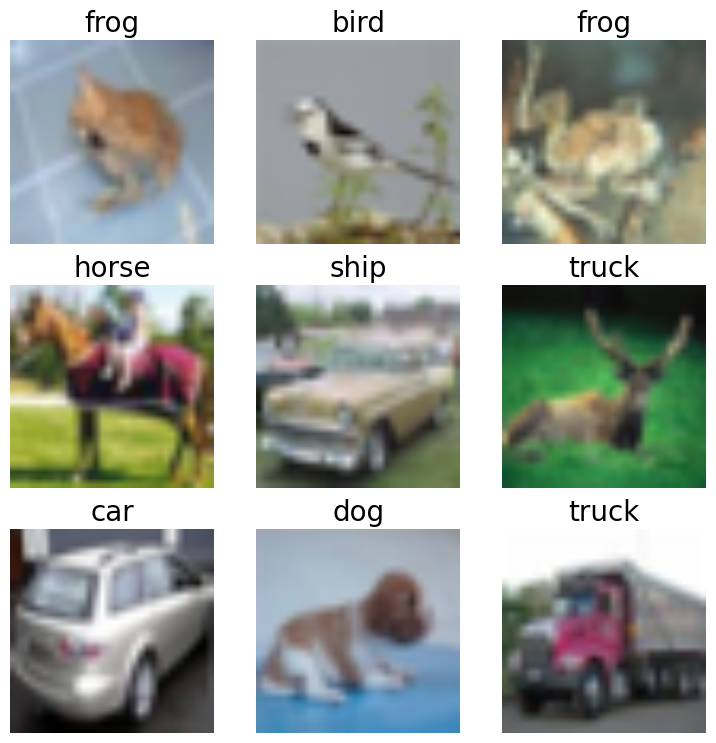

In [7]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Code to display images
batch_idx, (images, targets) = next(enumerate(train_loader))


fig, ax = plt.subplots(3,3,figsize = (9,9))
for i in range(3):
    for j in range(3):
        image = images[i*3+j].permute(1,2,0)
        image = image/2 + 0.5
        ax[i,j].imshow(image)
        ax[i,j].set_axis_off()
        ax[i,j].set_title(f'{classes[targets[i*3+j]]}', fontsize=20)
fig.show()

# Mixup Test 1 epoch
Checkpoint 2 code for Mixup test for 1 epoch.

In [9]:
# Directly train the whole model.
start = time.time()
#----------- <Your code> ---------------
# Reload Resnet18 in case of changes
resnetMixup = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Have to edit last layer to 10 output channels for CIFAR10 match
num_features = resnetMixup.fc.in_features
resnetMixup.fc = nn.Linear(num_features, 10)

# Send to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnetMixup = resnetMixup.to(device)

criterion = nn.CrossEntropyLoss()
max_epoch = 1

optimizer = optim.SGD(resnetMixup.parameters(), lr=0.001, momentum=0.9)

# Mixup Training for one
for epoch in range(1, max_epoch + 1):
    trainMixup(resnetMixup, criterion, optimizer, train_loader, epoch, alpha=1.0)
    testMixup(resnetMixup, criterion, test_loader, epoch)

finalStats = testMixup(resnetMixup, criterion, test_loader, epoch)
end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/50000] Loss: 2.445
Epoch 1: [6208/50000] Loss: 2.116
Epoch 1: [12416/50000] Loss: 2.077
Epoch 1: [18624/50000] Loss: 1.950
Epoch 1: [24832/50000] Loss: 1.761
Epoch 1: [31040/50000] Loss: 1.611
Epoch 1: [37248/50000] Loss: 1.604
Epoch 1: [43456/50000] Loss: 1.558
Epoch 1: [49664/50000] Loss: 1.332
Test result on epoch 1: total sample: 10000, Avg loss: 0.704, Acc: 87.890%
Test result on epoch 1: total sample: 10000, Avg loss: 0.704, Acc: 87.890%
Finished Training after 46.232420682907104 s 


# Mixup Visualization of incorrect Predicitions
Adapted from Assignment 3: CNN code.

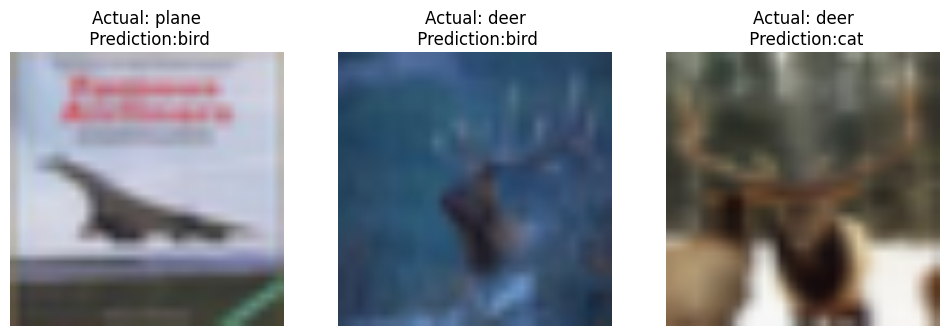

In [10]:

predictions = finalStats['prediction']

total_images = 3
targets = torch.tensor(testset.targets)

# Mask values (True = wrong)
incorrect = (predictions != targets)

# Index for wrong values
# Refer https://docs.pytorch.org/docs/stable/generated/torch.where.html
misclassified = torch.where(incorrect)[0]

# Select images
sampleIdx = misclassified[:total_images]

# Plot
fig, ax = plt.subplots(1, total_images, figsize = (12,4))

for i in range(total_images):
  image , trueLabel = testset[sampleIdx[i]]
  # Move to CPU and detach
  image = image.detach().cpu()
  predLabel = predictions[sampleIdx[i]].item()
  image = image/2 + 0.5
  image = image.permute(1,2,0)

  ax[i].imshow(image)
  ax[i].set_axis_off()
  ax[i].set_title("Actual: " + classes[trueLabel] + "\n Prediction:" + classes[predLabel])

# ERM and Mixup Setup for Data Collection (NECESSARY FOR MULTI EPOCH) (Shared Parameters Inside)


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ERM Setup
resnetERM = models.resnet18(weights=None) # load resnet without any trained weights

# Have to edit last layer to 10 output channels for CIFAR10 match
num_features = resnetERM.fc.in_features
resnetERM.fc = nn.Linear(num_features, 10)

# Send to GPU
resnetERM = resnetERM.to(device)


# Shared Parameter Selection
criterion = nn.CrossEntropyLoss()
maxEpoch = 50
learnRate = 0.001

# Adam optimizer ERM
optimizerERM = optim.Adam(resnetERM.parameters(), lr=learnRate)

# Mixup Setup

resnetMixup = models.resnet18(weights=None) # load resnet without any trained weights

# Have to edit last layer to 10 output channels for CIFAR10 match
num_features = resnetMixup.fc.in_features
resnetMixup.fc = nn.Linear(num_features, 10)

# Send to GPU
resnetMixup = resnetMixup.to(device)

# Adam optimizer Mixup
optimizerMixup = optim.Adam(resnetMixup.parameters(), lr=learnRate)



# Training ERM MULTI EPOCH

In [12]:
# Storage for accuracy and loss
ermAccuracyList = []
ermLossList = []

start = time.time()

# Epoch training loop and appending stats
for epoch in range(1, maxEpoch + 1):
    train(resnetERM, criterion, optimizerERM, train_loader, epoch)
    ermStats = test(resnetERM, criterion, test_loader, epoch)
    ermAccuracyList.append(ermStats['accuracy'])
    ermLossList.append(ermStats['loss'])

end = time.time()
print(f'Finished Training after {end-start} s ')


Epoch 1: [0/50000] Loss: 2.313
Epoch 1: [6208/50000] Loss: 2.049
Epoch 1: [12416/50000] Loss: 1.931
Epoch 1: [18624/50000] Loss: 2.043
Epoch 1: [24832/50000] Loss: 1.743
Epoch 1: [31040/50000] Loss: 1.836
Epoch 1: [37248/50000] Loss: 1.706
Epoch 1: [43456/50000] Loss: 1.571
Epoch 1: [49664/50000] Loss: 1.566
Test result on epoch 1: total sample: 10000, Avg loss: 1.372, Acc: 51.610%
Epoch 2: [0/50000] Loss: 1.612
Epoch 2: [6208/50000] Loss: 1.620
Epoch 2: [12416/50000] Loss: 1.506
Epoch 2: [18624/50000] Loss: 1.714
Epoch 2: [24832/50000] Loss: 1.516
Epoch 2: [31040/50000] Loss: 1.612
Epoch 2: [37248/50000] Loss: 1.534
Epoch 2: [43456/50000] Loss: 1.495
Epoch 2: [49664/50000] Loss: 1.525
Test result on epoch 2: total sample: 10000, Avg loss: 1.049, Acc: 66.850%
Epoch 3: [0/50000] Loss: 1.332
Epoch 3: [6208/50000] Loss: 1.248
Epoch 3: [12416/50000] Loss: 0.920
Epoch 3: [18624/50000] Loss: 1.595
Epoch 3: [24832/50000] Loss: 1.661
Epoch 3: [31040/50000] Loss: 1.420
Epoch 3: [37248/50000] Lo

# Training Mixup MULTI EPOCH

In [10]:
alphaVal = 1.0 # Hyper parameter for mixing weight

# storage for accuracy and loss
mixupAccuracyList = []
mixupLossList = []

start = time.time() # Track time

# Epoch loop of training and testing then saving to lists
for epoch in range(1, maxEpoch + 1):
    trainMixup(resnetMixup, criterion, optimizerMixup, train_loader, epoch, alpha=alphaVal)
    mixupStats = testMixup(resnetMixup, criterion, test_loader, epoch)
    mixupAccuracyList.append(mixupStats['accuracy'])
    mixupLossList.append(mixupStats['loss'])

end = time.time()
print(f'Finished Training after {end-start} s ')

Epoch 1: [0/50000] Loss: 2.532
Epoch 1: [6208/50000] Loss: 2.171
Epoch 1: [12416/50000] Loss: 2.043
Epoch 1: [18624/50000] Loss: 2.110
Epoch 1: [24832/50000] Loss: 2.144
Epoch 1: [31040/50000] Loss: 1.951
Epoch 1: [37248/50000] Loss: 1.975
Epoch 1: [43456/50000] Loss: 2.064
Epoch 1: [49664/50000] Loss: 2.242
Test result on epoch 1: total sample: 10000, Avg loss: 1.446, Acc: 52.970%
Epoch 2: [0/50000] Loss: 1.933
Epoch 2: [6208/50000] Loss: 1.936
Epoch 2: [12416/50000] Loss: 1.873
Epoch 2: [18624/50000] Loss: 2.095
Epoch 2: [24832/50000] Loss: 1.473
Epoch 2: [31040/50000] Loss: 1.953
Epoch 2: [37248/50000] Loss: 1.652
Epoch 2: [43456/50000] Loss: 1.847
Epoch 2: [49664/50000] Loss: 1.773
Test result on epoch 2: total sample: 10000, Avg loss: 1.219, Acc: 61.860%
Epoch 3: [0/50000] Loss: 1.577
Epoch 3: [6208/50000] Loss: 2.020
Epoch 3: [12416/50000] Loss: 1.716
Epoch 3: [18624/50000] Loss: 1.918
Epoch 3: [24832/50000] Loss: 1.908
Epoch 3: [31040/50000] Loss: 1.677
Epoch 3: [37248/50000] Lo

# Export Multi Epoch Comparison as CSV

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Dicitionary for ease in csv making
dataCompare = {
    'Epoch': range(1, maxEpoch+1),
    'ermAccuracy' : ermAccuracyList,
    'ermLoss' : ermLossList,
    'mixupAccuracy' : mixupAccuracyList,
    'mixupLoss' : mixupLossList
}

df = pd.DataFrame(dataCompare) # Place into datafame
csvName = f"ermVSmixup_Epochs{maxEpoch}_lr{learnRate}_corupt{int(corruptLevel*100)}_optimAdam.csv" # info rich name

# Uncomment to save to gdrive
csvName= f'/content/drive/MyDrive/HW3andProject/{csvName}'

df.to_csv(csvName, index=False)

# Visualize Data

## Visualize Test accuracy for single csv

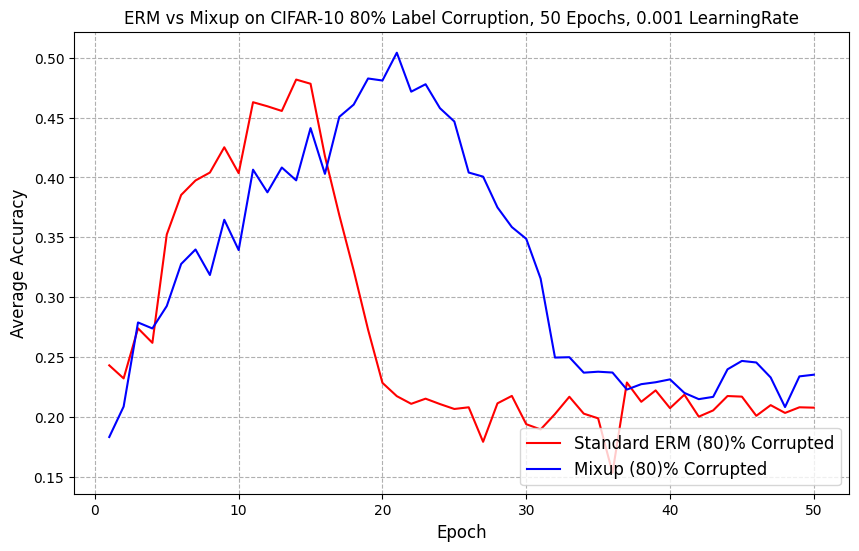

In [16]:
fileName = 'ermVSmixup_Epochs50_lr0.001_corupt80_optimAdam.csv'

# Ommit if saved locally in Google Colab
fileName = f'/content/drive/MyDrive/HW3andProject/{fileName}'

data = pd.read_csv(fileName) # parse csv


splitName = fileName.split('_') # split file name to determine test parameters

epochs = int(splitName[1].split('s')[1]) # remove amount of epochs after the letter 's'
lRate = float(splitName[2].split('r')[1]) # remove amount of learningRate after the letter 'r'
corrupt = int(splitName[3].split('t')[1]) # remove amount of coruption after the letter 't'

plt.figure(figsize=(10,6))

# Set trace parameters
plt.plot(data['Epoch'], data['ermAccuracy'], linestyle = '-', color ='red', label=f'Standard ERM ({corrupt})% Corrupted')
plt.plot(data['Epoch'], data['mixupAccuracy'], linestyle = '-', color ='blue', label=f'Mixup ({corrupt})% Corrupted')

# Edit labels
plt.title(f'ERM vs Mixup on CIFAR-10 {corrupt}% Label Corruption, {epochs} Epochs, {lRate} LearningRate')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Accuracy', fontsize=12)

# Set legend and grid
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--')

plt.show()



## Visualize Test accuracy for multiple csv's

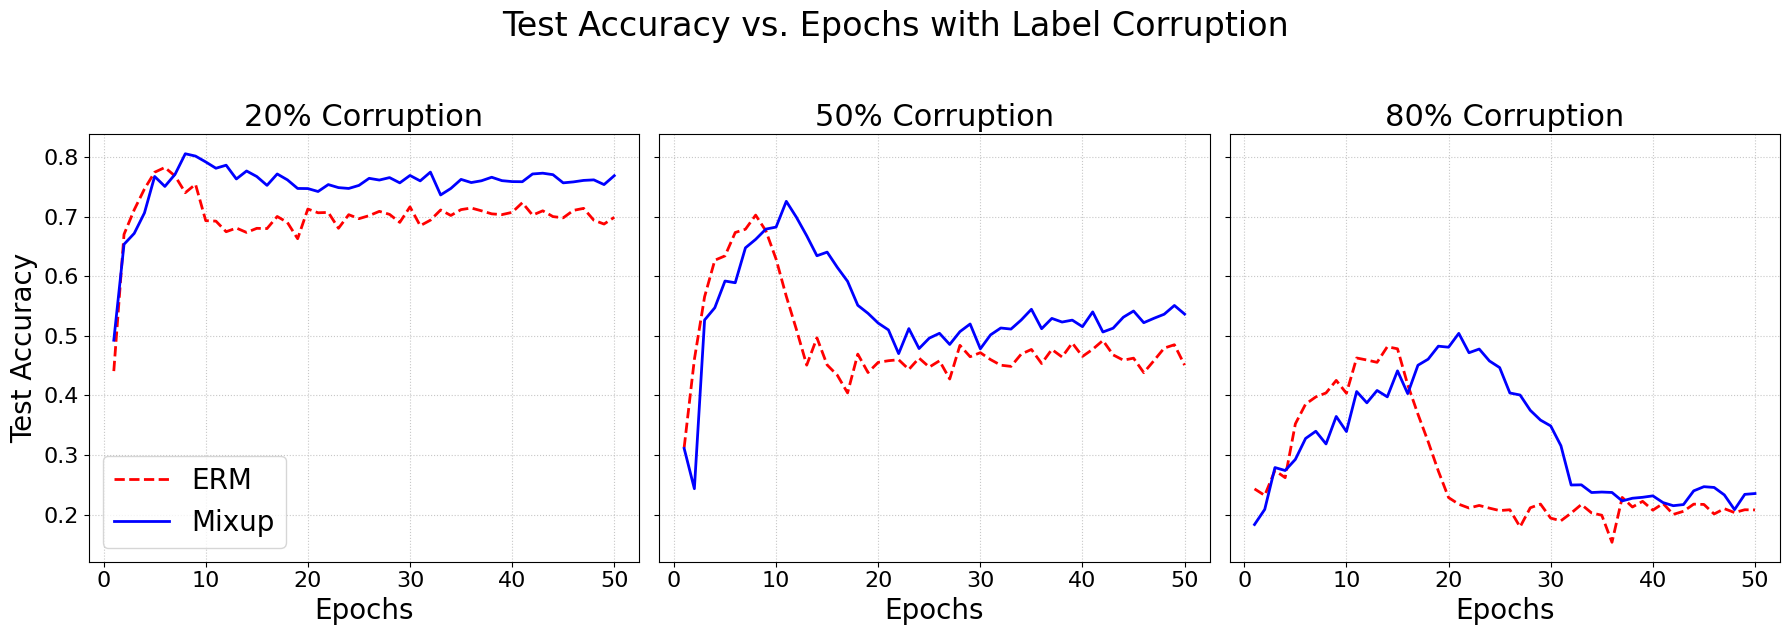

In [17]:
# Load data
df_20 = pd.read_csv('/content/drive/MyDrive/HW3andProject/ermVSmixup_Epochs50_lr0.001_corupt20_optimAdam.csv')
df_50 = pd.read_csv('/content/drive/MyDrive/HW3andProject/ermVSmixup_Epochs50_lr0.001_corupt50_optimAdam.csv')
df_80 = pd.read_csv('/content/drive/MyDrive/HW3andProject/ermVSmixup_Epochs50_lr0.001_corupt80_optimAdam.csv')

fontsize = 20 # Fontsize to size up to input into paper

# Configure for 3 datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Test Accuracy vs. Epochs with Label Corruption', fontsize=fontsize+4, y=1.05)

datasets = [(df_20, '20% Corruption'), (df_50, '50% Corruption'), (df_80, '80% Corruption')]


# Loop through datasets and plot data
for ax, (df, title) in zip(axes, datasets):
    ax.tick_params(axis='both', which='major', labelsize=fontsize-4)
    ax.plot(df['Epoch'], df['ermAccuracy'], label='ERM', color='red', linewidth=2, linestyle='--')
    ax.plot(df['Epoch'], df['mixupAccuracy'], label='Mixup', color='blue', linewidth=2)
    ax.set_title(title, fontsize=fontsize+2)
    ax.set_xlabel('Epochs', fontsize=fontsize)
    ax.grid(True, linestyle=':', alpha=0.7)

    # Create Test Accuracy label on left
    if ax == axes[0]:
        ax.set_ylabel('Test Accuracy', fontsize=fontsize)
        ax.legend(fontsize=fontsize)

# Tigheten adjacent graphs
plt.tight_layout()
plt.show()

## Visualize Test Loss for multiple csv's

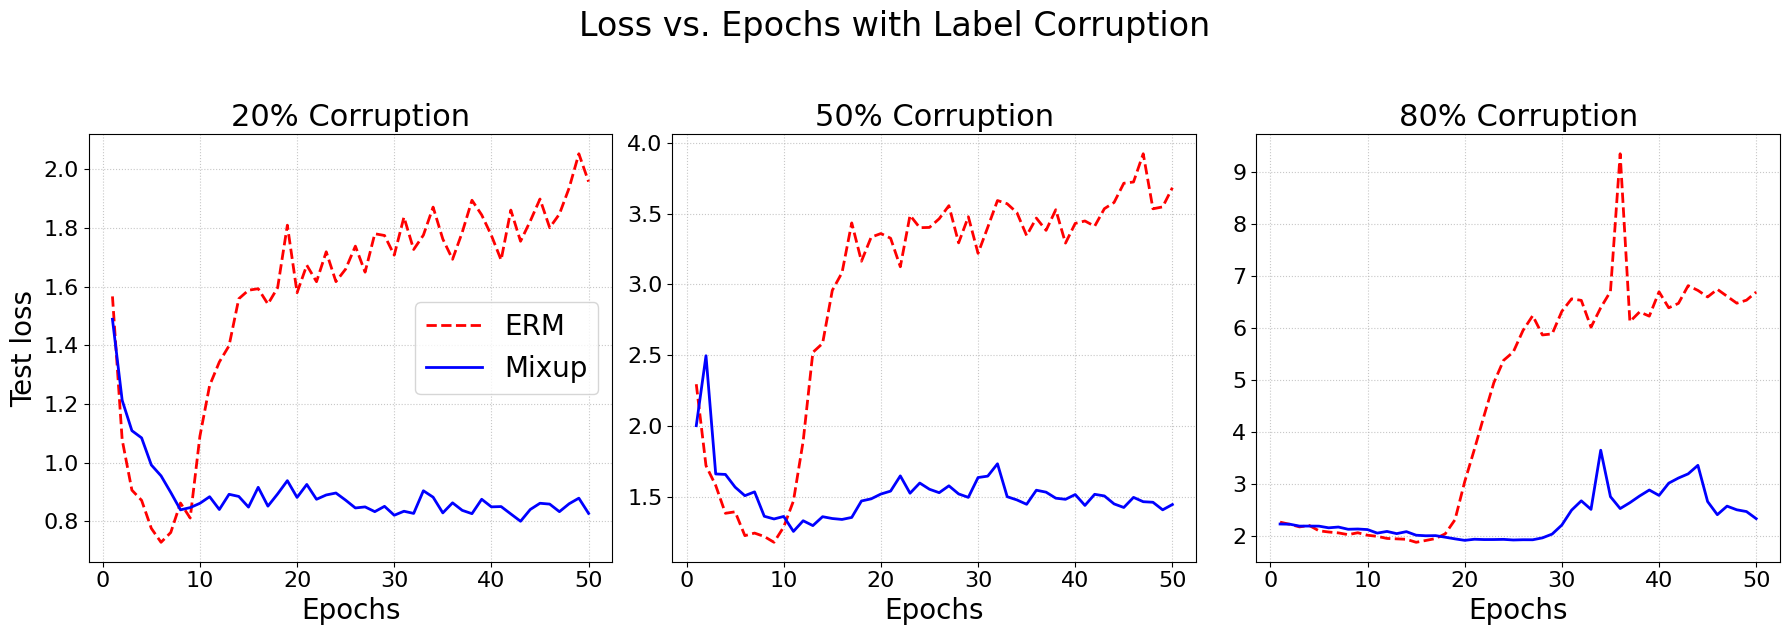

In [18]:
df_20 = pd.read_csv('/content/drive/MyDrive/HW3andProject/ermVSmixup_Epochs50_lr0.001_corupt20_optimAdam.csv')
df_50 = pd.read_csv('/content/drive/MyDrive/HW3andProject/ermVSmixup_Epochs50_lr0.001_corupt50_optimAdam.csv')
df_80 = pd.read_csv('/content/drive/MyDrive/HW3andProject/ermVSmixup_Epochs50_lr0.001_corupt80_optimAdam.csv')


fontsize = 20 # Fontsize to size up to input into paper

# Configure for 3 datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle('Loss vs. Epochs with Label Corruption', fontsize=fontsize+4, y=1.05)

datasets = [(df_20, '20% Corruption'), (df_50, '50% Corruption'), (df_80, '80% Corruption')]


# Loop through datasets and plot data
for ax, (df, title) in zip(axes, datasets):
    ax.tick_params(axis='both', which='major', labelsize=fontsize-4)
    ax.plot(df['Epoch'], df['ermLoss'], label='ERM', color='red', linewidth=2, linestyle='--')
    ax.plot(df['Epoch'], df['mixupLoss'], label='Mixup', color='blue', linewidth=2)
    ax.set_title(title, fontsize=fontsize+2)
    ax.set_xlabel('Epochs', fontsize=fontsize)
    ax.grid(True, linestyle=':', alpha=0.7)

    # Create Test Accuracy label on left
    if ax == axes[0]:
        ax.set_ylabel('Test loss', fontsize=fontsize)
        ax.legend(fontsize=fontsize)

# Tigheten adjacent graphs
plt.tight_layout()
plt.show()